# 16 — Smoothing before Chebyshev projection (Gaussian / Savitzky–Golay)

Pre-smooth raw GaiaXPy calibrated spectra along wavelength, **L2-normalize**, fit **Chebyshev** at several degrees **K ∈ {10, 20, 30, 40, 50}** (so **K+1** coefficients each), then classify with **fixed Logistic Regression** (`StandardScaler` + `lbfgs`, `C=1`, `class_weight='balanced'`) on the same **50 RSKF splits** as other experiments (`splits_rskf.json`). The same Gaussian / Savitzky–Golay sweep is repeated for every K so you can check whether smoothing matters when the basis has enough capacity to retain high-frequency structure.

**Outputs:** `results/smoothing_results_logreg.csv` (column `cheb_deg`), `smoothing_summary_logreg.csv`, `smoothing_summary_logreg.png` (PR-AUC panels per K), `smoothing_vs_focused_lr__K{degree}.png` (one file per Chebyshev degree: 4 metric rows × {Gaussian, Savgol} vs focused `chebyshev_{K}_L2` + LR), plus `smoothing_vs_focused_lr_by_cheb_k.png` (duplicate of the first K in `CHEB_DEGREES`).

Threshold for F1 / precision / recall / specificity: **Youden J** on training `predict_proba` (same spirit as `05_classify_focused` / `12_fpca_classifier`; scores are already in $[0,1]$ so no extra calibration).

### What are “grid points” on the x-axis?

Each column of the calibrated spectrum matrix is one **wavelength sample** from `GaiaXPy` / `xp_sampled_spectra.csv` (here ~343 bins from ~336–1020 nm, spacing ≈ mean Δλ nm). **Grid points** are that column index: Gaussian **σ** is the smoothing scale in **bins** along λ; Savitzky–Golay **window** is the number of **bins** in the sliding window. The top x-axis (nm) is only **param × mean(Δλ)** — a rough physical scale, not a separate measurement.

In [7]:
from __future__ import annotations

import csv
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial.chebyshev import Chebyshev
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Quick test: only rep0 folds (5 splits). Set False for full 10×5 experiment.
SMOKE = False

GAUSSIAN_SIGMAS = [0, 1, 2, 5, 10, 20]
SAVGOL_WINDOWS = [1, 5, 11, 21, 41, 81]
SAVGOL_POLYORDER = 3
# Chebyshev degree K (number of coefficients = K+1). Same smoothing sweep for each K.
CHEB_DEGREES = [10, 20, 30, 40, 50]

# Uncertainty shown in plots (summary CSV still stores both *_std and *_ci95):
#   "ci95_mean" — 95% CI for the *mean* score across folds (SEM × t); narrow when n_folds is large.
#   "std_folds" — ±1 sample SD of fold scores (spread fold-to-fold); wider, easier to see.
ERROR_BAND = "ci95_mean"

EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
DATA_DIR = EXPERIMENT_DIR / "data"
RESULTS_DIR = EXPERIMENT_DIR / "results"
POC_DIR = Path("transformation_poc") if Path("transformation_poc").exists() else Path("..") / "transformation_poc"
RESULTS_DIR.mkdir(exist_ok=True)

RESULTS_CSV = RESULTS_DIR / "smoothing_results_logreg.csv"
SUMMARY_CSV = RESULTS_DIR / "smoothing_summary_logreg.csv"
FIG_PATH = RESULTS_DIR / "smoothing_summary_logreg.png"
FIG_COMPARE_PATH = RESULTS_DIR / "smoothing_vs_focused_lr_by_cheb_k.png"
FOCUSED_RESULTS_CSV = RESULTS_DIR / "focused_experiment_results.csv"

print("EXPERIMENT_DIR:", EXPERIMENT_DIR.resolve())
print("POC_DIR:       ", POC_DIR.resolve())
print("SMOKE:         ", SMOKE)
print("Chebyshev K:   ", CHEB_DEGREES)
print("Plot error band:", ERROR_BAND, "(see cell 2 comment)")

EXPERIMENT_DIR: /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment
POC_DIR:        /Users/erikak/Documents/uni/bakalauras/kodas/transformation_poc
SMOKE:          False
Chebyshev K:    [10, 20, 30, 40, 50]
Plot error band: ci95_mean (see cell 2 comment)


In [8]:
df_og = pd.read_csv(DATA_DIR / "og_xp.csv")
df_spec = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv")
wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)
grid_step_nm = float(np.mean(np.diff(wavelengths)))

spec_idx = df_spec.set_index("source_id")
missing = set(df_og["source_id"]) - set(spec_idx.index)
assert not missing, f"Missing spectra for {len(missing)} source_ids"
F_raw = spec_idx.loc[df_og["source_id"], wl_cols].to_numpy(dtype=np.float64)
y = df_og["y"].to_numpy(dtype=np.int64)

assert F_raw.shape[0] == len(df_og) == len(y)
assert spec_idx.loc[df_og["source_id"]].index.duplicated().sum() == 0

with open(DATA_DIR / "splits_rskf.json") as f:
    splits = json.load(f)
if SMOKE:
    splits = {k: v for k, v in splits.items() if k.startswith("rep0_")}


def split_sort_key(k: str):
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)


split_names = sorted(splits.keys(), key=split_sort_key)
split_enum = list(enumerate(split_names))

n_pos = int((y == 1).sum())
n_neg = int((y == 0).sum())

print(f"N = {len(y)}, wavelength bins = {F_raw.shape[1]}, Δλ ≈ {grid_step_nm:.3f} nm")
print(f"Class balance: neg={n_neg}, pos={n_pos}")
print(f"Splits: {len(split_names)}")
print(
    "Grid points: index along the calibrated wavelength axis (one bin per column of F_raw); "
    "Gaussian σ and Savitzky–Golay window are in these bins (not arcsec). "
    f"Approx. nm scale ≈ param × {grid_step_nm:.3f} nm."
)

N = 2815, wavelength bins = 343, Δλ ≈ 2.000 nm
Class balance: neg=2257, pos=558
Splits: 50
Grid points: index along the calibrated wavelength axis (one bin per column of F_raw); Gaussian σ and Savitzky–Golay window are in these bins (not arcsec). Approx. nm scale ≈ param × 2.000 nm.


In [9]:
def smooth_gaussian(F: np.ndarray, sigma: float) -> np.ndarray:
    if sigma == 0:
        return F.copy()
    return gaussian_filter1d(F, sigma=sigma, axis=1, mode="nearest")


def smooth_savgol(F: np.ndarray, window_length: int) -> np.ndarray:
    if window_length == 1:
        return F.copy()
    return savgol_filter(
        F,
        window_length=window_length,
        polyorder=SAVGOL_POLYORDER,
        axis=1,
        mode="nearest",
    )


def l2_normalize_rows(F: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(F, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-15)
    return F / norms


def chebyshev_coeff_matrix(F: np.ndarray, wl: np.ndarray, deg: int) -> np.ndarray:
    """F: (n_stars, n_bins) — one row per star after smoothing + L2."""
    n = F.shape[0]
    out = np.empty((n, deg + 1), dtype=np.float64)
    for i in range(n):
        c = Chebyshev.fit(wl, F[i], deg=deg)
        out[i] = c.coef
    return out


def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)
    return best_thr


def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    z = 0
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=z)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=z)
    spec = recall_score(y_true, y_pred, pos_label=0, zero_division=z)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=z)
    return prec, rec, spec, f1


lr_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE,
                solver="lbfgs",
                C=1.0,
                class_weight="balanced",
            ),
        ),
    ]
)


def eval_fold(X, y_arr, train_idx, test_idx):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
    pipe = clone(lr_pipeline)
    pipe.fit(X_tr, y_tr)
    p_tr = pipe.predict_proba(X_tr)[:, 1]
    p_te = pipe.predict_proba(X_te)[:, 1]
    thr = pick_youden_threshold(y_tr, p_tr)
    pr_auc = average_precision_score(y_te, p_te)
    try:
        roc_auc = float(roc_auc_score(y_te, p_te))
    except ValueError:
        roc_auc = float("nan")
    prec, rec, spec, f1v = metrics_at_threshold(y_te, p_te, thr)
    return {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "f1": f1v,
        "precision": prec,
        "recall": rec,
        "specificity": spec,
    }



In [10]:
FIELDNAMES = [
    "method",
    "param",
    "param_nm",
    "cheb_deg",
    "split_idx",
    "pr_auc",
    "roc_auc",
    "f1",
    "precision",
    "recall",
    "specificity",
]

# One-time migration: older CSVs had only K=10 implicitly (no cheb_deg column).
if RESULTS_CSV.exists() and RESULTS_CSV.stat().st_size > 0:
    prev = pd.read_csv(RESULTS_CSV)
    if "cheb_deg" not in prev.columns:
        prev["cheb_deg"] = 10
        prev = prev[FIELDNAMES]
        prev.to_csv(RESULTS_CSV, index=False)
        print(f"Migrated {RESULTS_CSV.name}: added cheb_deg=10 to all existing rows.")

completed = set()
if RESULTS_CSV.exists() and RESULTS_CSV.stat().st_size > 0:
    prev = pd.read_csv(RESULTS_CSV)
    if "cheb_deg" not in prev.columns:
        prev["cheb_deg"] = 10
    for _, r in prev.iterrows():
        completed.add(
            (str(r["method"]), int(r["param"]), int(r["cheb_deg"]), int(r["split_idx"]))
        )
    print(f"Resume: {len(completed)} fold-rows already in {RESULTS_CSV.name}")

file_exists = RESULTS_CSV.exists() and RESULTS_CSV.stat().st_size > 0

configs = []
for s in GAUSSIAN_SIGMAS:
    configs.append(("gaussian", int(s), smooth_gaussian(F_raw, float(s))))
for w in SAVGOL_WINDOWS:
    configs.append(("savgol", int(w), smooth_savgol(F_raw, int(w))))

new_rows = 0
for cheb_deg in CHEB_DEGREES:
    for method, param, F_s in configs:
        param_nm = param * grid_step_nm
        F_n = l2_normalize_rows(F_s)
        X_cheb = chebyshev_coeff_matrix(F_n, wavelengths, cheb_deg)
        for split_idx, sname in split_enum:
            if (method, param, cheb_deg, split_idx) in completed:
                continue
            tr = np.array(splits[sname]["train"], dtype=int)
            te = np.array(splits[sname]["test"], dtype=int)
            m = eval_fold(X_cheb, y, tr, te)
            row = {
                "method": method,
                "param": param,
                "param_nm": param_nm,
                "cheb_deg": cheb_deg,
                "split_idx": split_idx,
                **m,
            }
            write_header = not file_exists
            with open(RESULTS_CSV, "a", newline="") as f:
                w = csv.DictWriter(f, fieldnames=FIELDNAMES)
                if write_header:
                    w.writeheader()
                w.writerow(row)
            file_exists = True
            completed.add((method, param, cheb_deg, split_idx))
            new_rows += 1

print(f"Done. Appended {new_rows} new rows → {RESULTS_CSV}")

Resume: 3000 fold-rows already in smoothing_results_logreg.csv
Done. Appended 0 new rows → /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_results_logreg.csv


,cheb_deg,method,param,n_folds,pr_mean,pr_std,roc_mean,roc_std,rec_mean,rec_std,...,prec_std,pr_ci95,roc_ci95,rec_ci95,prec_ci95,pr_plot_half,roc_plot_half,rec_plot_half,prec_plot_half,param_nm
0,10,gaussian,0,50,0.794809,0.034365,0.899924,0.018037,0.780499,0.060767,...,0.073113,0.009767,0.005126,0.017270,0.020779,0.009767,0.005126,0.017270,0.020779,0.0
1,10,gaussian,1,50,0.795371,0.034270,0.900108,0.018015,0.771194,0.057843,...,0.068509,0.009739,0.005120,0.016439,0.019470,0.009739,0.005120,0.016439,0.019470,2.0
2,10,gaussian,2,50,0.796607,0.034322,0.900544,0.018046,0.774027,0.054986,...,0.066929,0.009754,0.005129,0.015627,0.019021,0.009754,0.005129,0.015627,0.019021,4.0
3,10,gaussian,5,50,0.801086,0.033997,0.901615,0.018033,0.765055,0.051145,...,0.059030,0.009662,0.005125,0.014535,0.016776,0.009662,0.005125,0.014535,0.016776,10.0
4,10,gaussian,10,50,0.803687,0.033954,0.901239,0.018241,0.758452,0.050947,...,0.065596,0.009650,0.005184,0.014479,0.018642,0.009650,0.005184,0.014479,0.018642,20.0
5,10,gaussian,20,50,0.798069,0.034884,0.897845,0.018161,0.745721,0.043245,...,0.043047,0.009914,0.005161,0.012290,0.012234,0.009914,0.005161,0.012290,0.012234,40.0
6,10,savgol,1,50,0.794809,0.034365,0.899924,0.018037,0.780499,0.060767,...,0.073113,0.009767,0.005126,0.017270,0.020779,0.009767,0.005126,0.017270,0.020779,2.0
7,10,savgol,5,50,0.794842,0.034323,0.899897,0.018027,0.780343,0.057159,...,0.070154,0.009755,0.005123,0.016244,0.019937,0.009755,0.005123,0.016244,0.019937,10.0
8,10,savgol,11,50,0.795345,0.034266,0.900171,0.017987,0.778901,0.055119,...,0.068007,0.009738,0.005112,0.015665,0.019328,0.009738,0.005112,0.015665,0.019328,22.0
9,10,savgol,21,50,0.796984,0.034188,0.900685,0.017951,0.770468,0.056403,...,0.067971,0.009716,0.005102,0.016030,0.019317,0.009716,0.005102,0.016030,0.019317,42.0


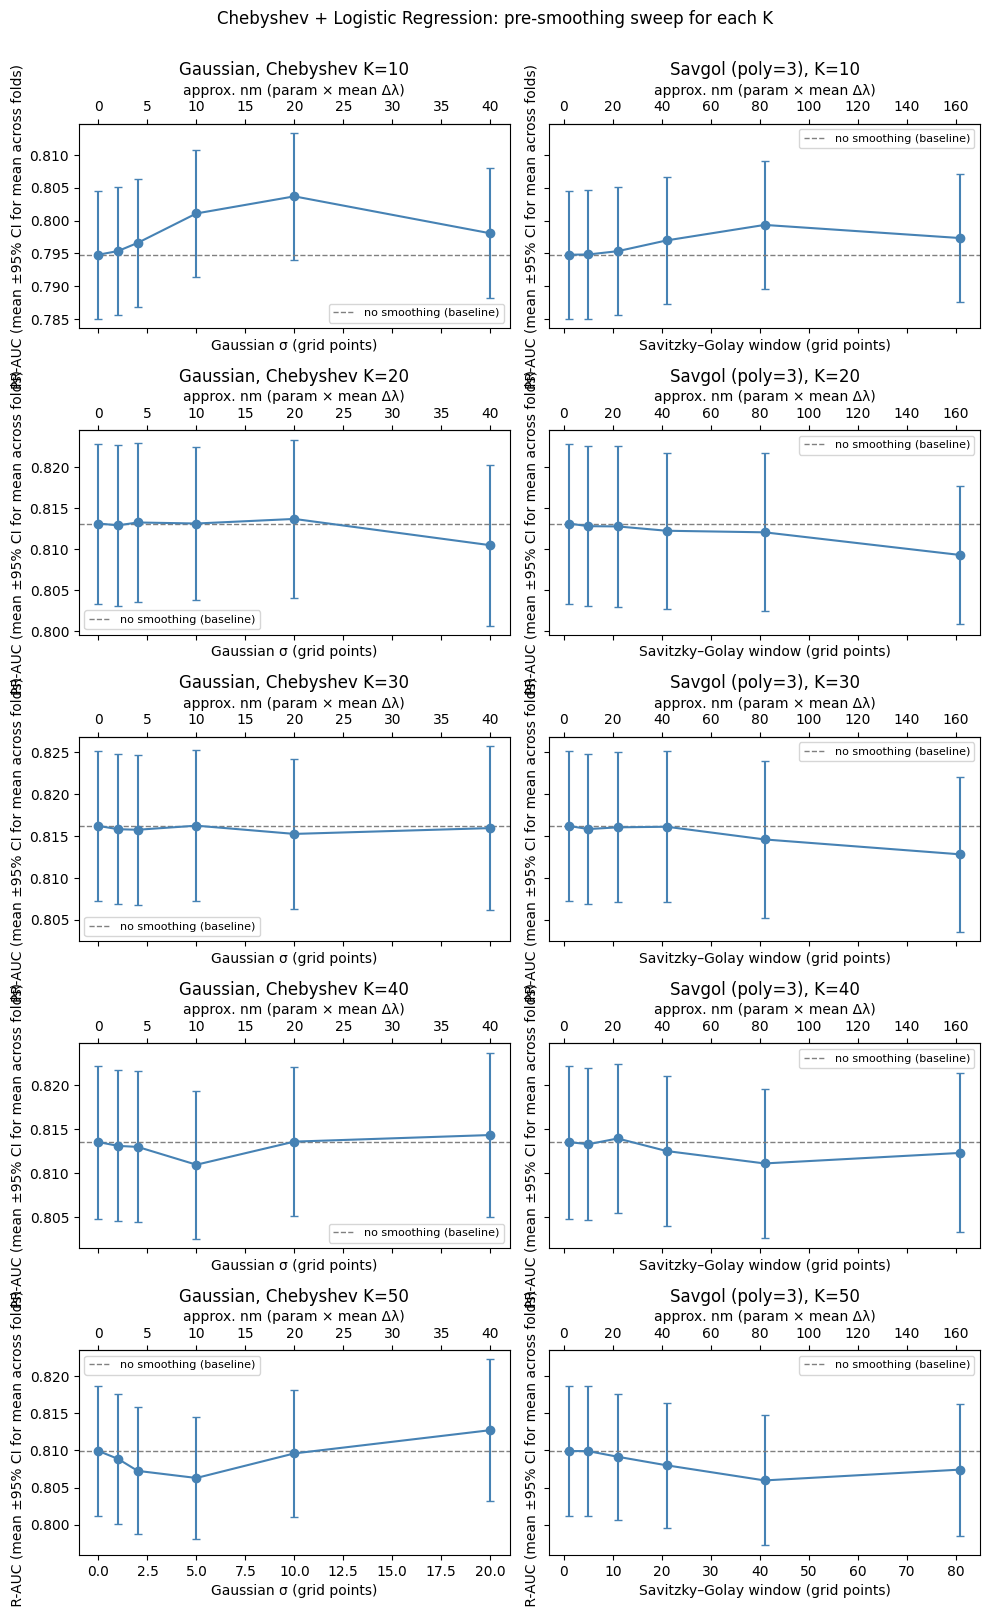

Saved /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_summary_logreg.png


In [11]:
from IPython.display import display
from scipy import stats

df_res = pd.read_csv(RESULTS_CSV)
if "cheb_deg" not in df_res.columns:
    df_res["cheb_deg"] = 10

summ = (
    df_res.groupby(["cheb_deg", "method", "param"], as_index=False)
    .agg(
        n_folds=("pr_auc", "count"),
        pr_mean=("pr_auc", "mean"),
        pr_std=("pr_auc", "std"),
        roc_mean=("roc_auc", "mean"),
        roc_std=("roc_auc", "std"),
        rec_mean=("recall", "mean"),
        rec_std=("recall", "std"),
        prec_mean=("precision", "mean"),
        prec_std=("precision", "std"),
    )
    .sort_values(["cheb_deg", "method", "param"])
)


def fold_scores_ci95_halfwidth(std: np.ndarray, n: np.ndarray) -> np.ndarray:
    """Half-width of 95% two-sided CI for the mean of fold-level scores."""
    std = np.asarray(std, dtype=float)
    n = np.asarray(n, dtype=int)
    half = np.zeros_like(std, dtype=float)
    for i in range(len(n)):
        ni = int(n[i])
        if ni > 1 and np.isfinite(std[i]):
            sem = std[i] / np.sqrt(ni)
            half[i] = float(stats.t.ppf(0.975, ni - 1)) * sem
    return half


_n = summ["n_folds"].to_numpy()
for prefix in ("pr", "roc", "rec", "prec"):
    summ[f"{prefix}_ci95"] = fold_scores_ci95_halfwidth(summ[f"{prefix}_std"].to_numpy(), _n)

# What to draw in figures (CSV keeps both *_std and *_ci95 for tables).
for prefix in ("pr", "roc", "rec", "prec"):
    if ERROR_BAND == "std_folds":
        summ[f"{prefix}_plot_half"] = summ[f"{prefix}_std"].fillna(0.0)
    else:
        summ[f"{prefix}_plot_half"] = summ[f"{prefix}_ci95"].fillna(0.0)

summ["param_nm"] = summ["param"] * grid_step_nm
summ.to_csv(SUMMARY_CSV, index=False)
display(summ)

n_k = len(CHEB_DEGREES)
fig_h = max(4.0, 3.2 * n_k)
fig, axes = plt.subplots(n_k, 2, figsize=(10, fig_h), sharex="col", sharey="row")
if n_k == 1:
    axes = np.reshape(axes, (1, -1))


def plot_panel_pr(ax, sub, baseline, xlabel_pts, title):
    x = sub["param"].to_numpy()
    ym = sub["pr_mean"].to_numpy()
    ys = sub["pr_plot_half"].fillna(0.0).to_numpy()
    band = "±1 SD across folds" if ERROR_BAND == "std_folds" else "±95% CI for mean across folds"
    ax.errorbar(x, ym, yerr=ys, fmt="o-", capsize=3, color="steelblue")
    ax.axhline(baseline, color="gray", ls="--", lw=1, label="no smoothing (baseline)")
    ax.set_xlabel(xlabel_pts)
    ax.set_ylabel(f"PR-AUC (mean {band})")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    sec = ax.secondary_xaxis("top", functions=(lambda v: v * grid_step_nm, lambda w: w / grid_step_nm))
    sec.set_xlabel("approx. nm (param × mean Δλ)")


for ri, kdeg in enumerate(CHEB_DEGREES):
    sub_k = summ[summ["cheb_deg"] == kdeg]
    g = sub_k[sub_k["method"] == "gaussian"].sort_values("param")
    s = sub_k[sub_k["method"] == "savgol"].sort_values("param")
    baseline_g = float(g.loc[g["param"] == 0, "pr_mean"].iloc[0])
    baseline_s = float(s.loc[s["param"] == 1, "pr_mean"].iloc[0])
    plot_panel_pr(
        axes[ri, 0],
        g,
        baseline_g,
        "Gaussian σ (grid points)",
        f"Gaussian, Chebyshev K={kdeg}",
    )
    plot_panel_pr(
        axes[ri, 1],
        s,
        baseline_s,
        "Savitzky–Golay window (grid points)",
        f"Savgol (poly={SAVGOL_POLYORDER}), K={kdeg}",
    )

fig.suptitle("Chebyshev + Logistic Regression: pre-smoothing sweep for each K", y=1.002)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", FIG_PATH.resolve())
plt.close(fig)

Focused baseline chebyshev_10_L2: 50 fold rows.
Focused baseline chebyshev_20_L2: 50 fold rows.
Focused baseline chebyshev_30_L2: 50 fold rows.
Focused baseline chebyshev_40_L2: 50 fold rows.
Focused baseline chebyshev_50_L2: 50 fold rows.


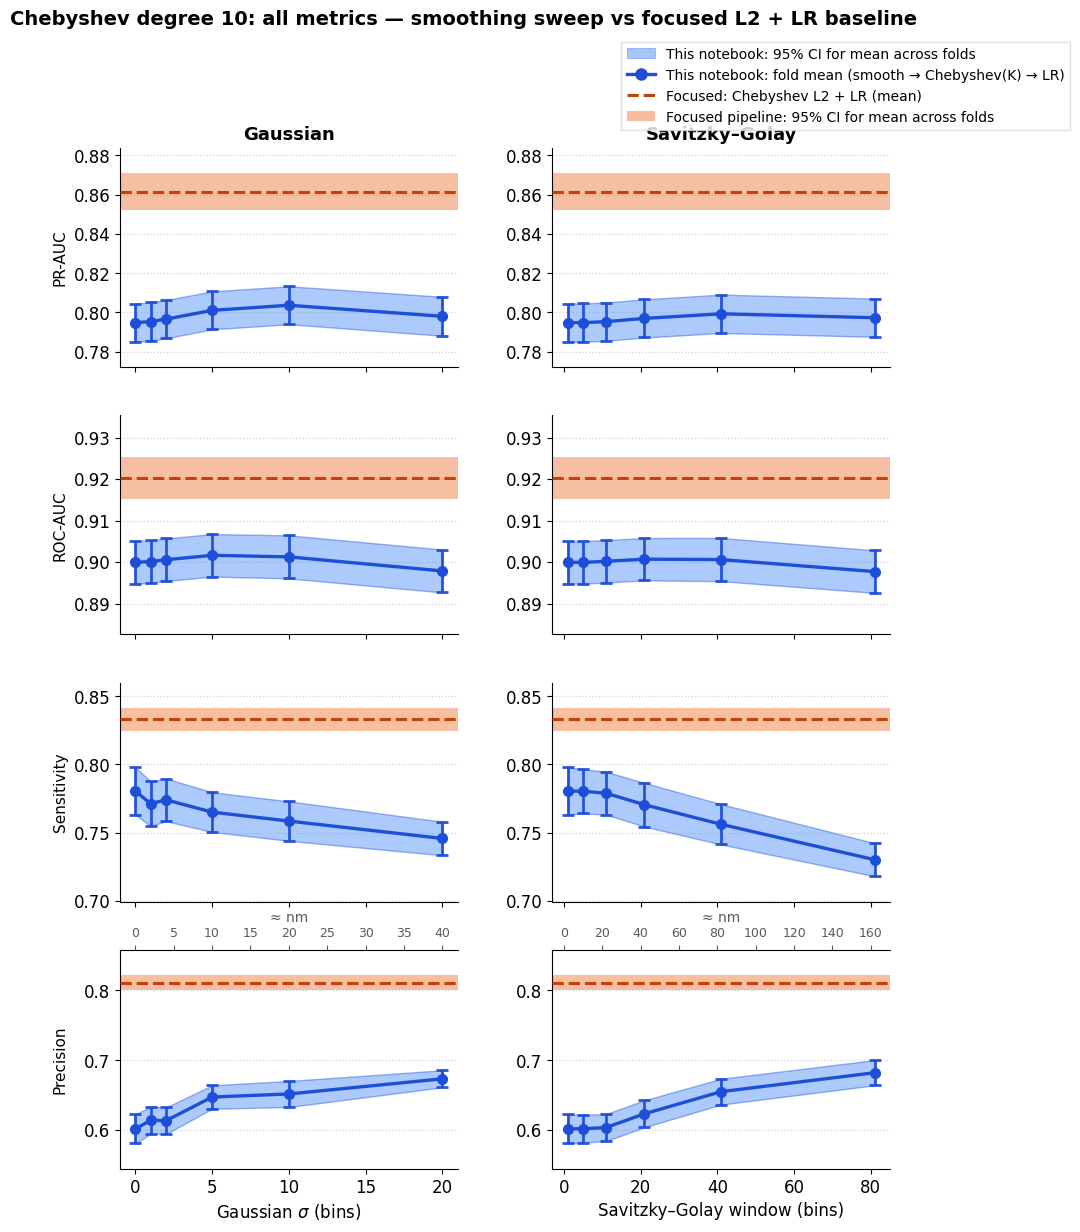

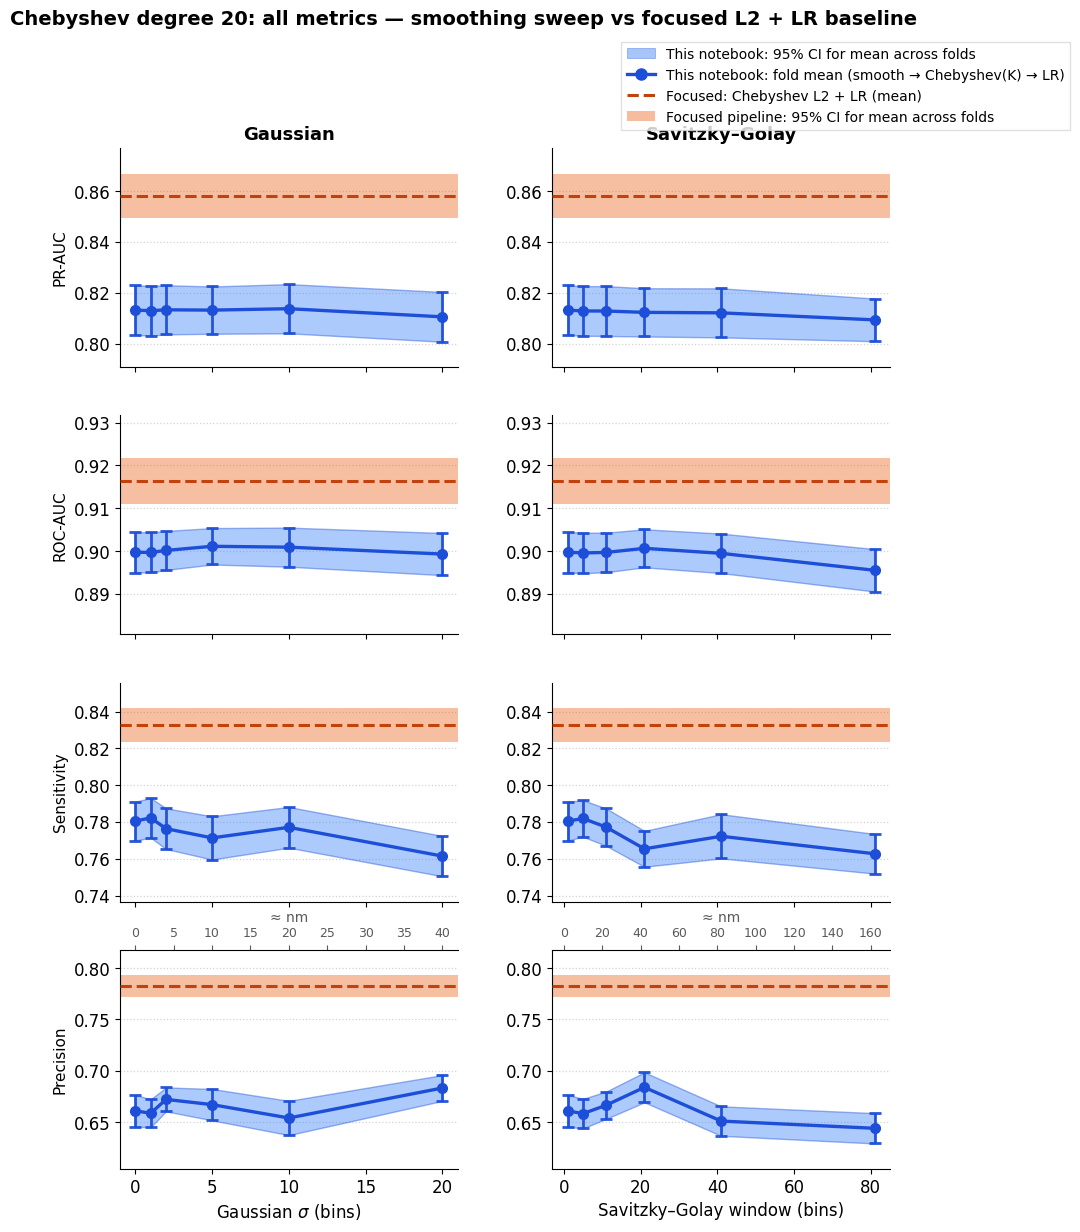

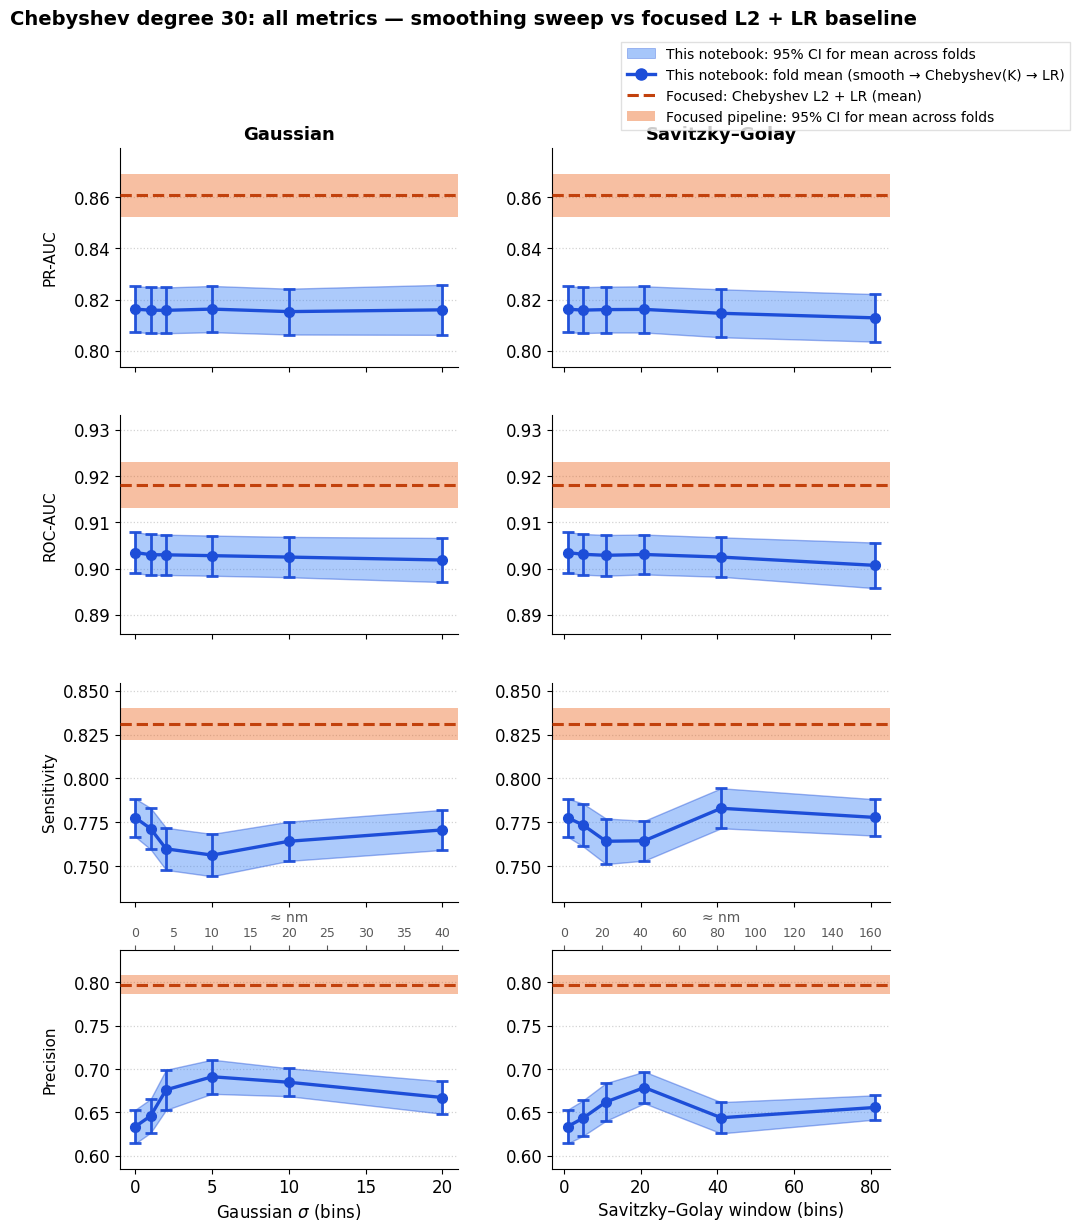

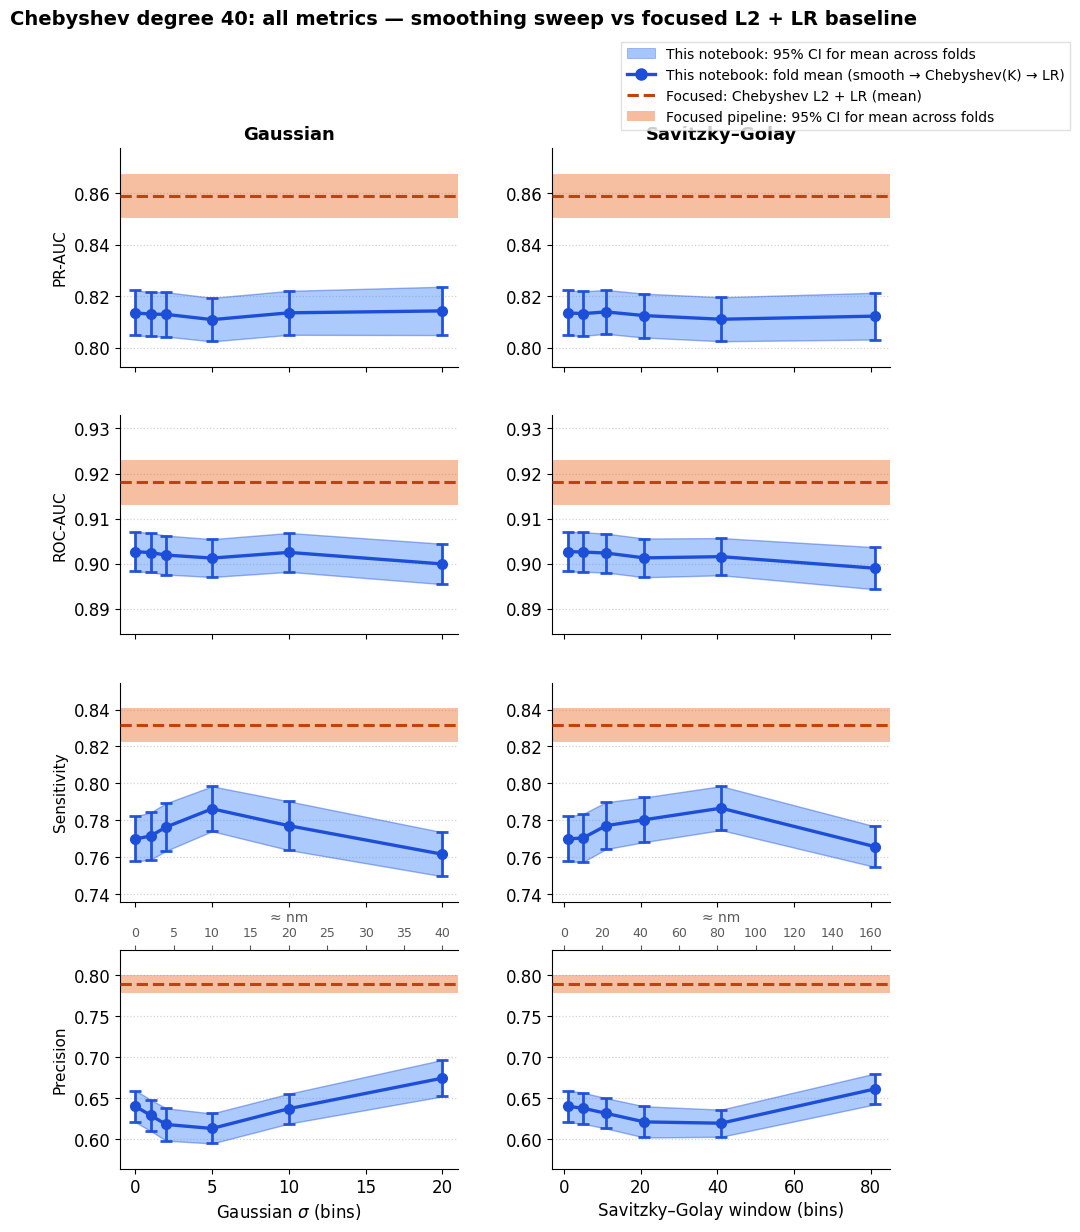

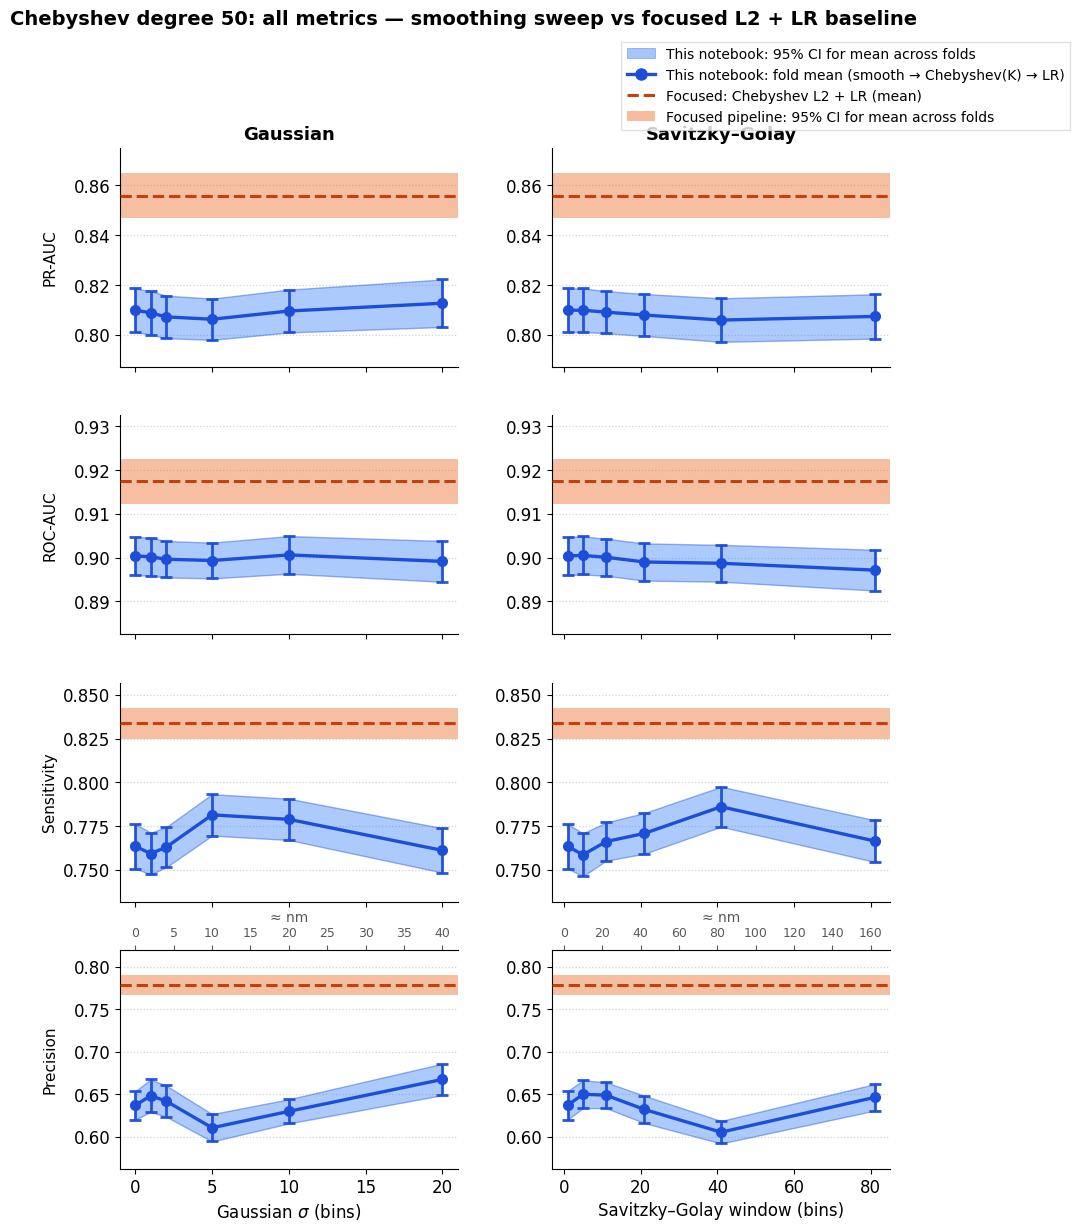

Saved (one figure per Chebyshev degree, all metrics in each):
  /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr__K10.png
  /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr__K20.png
  /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr__K30.png
  /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr__K40.png
  /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr__K50.png
Legacy path (same as first K in CHEB_DEGREES): /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/smoothing_vs_focused_lr_by_cheb_k.png


In [12]:
# Comparison: smoothing sweeps vs focused experiment (per Chebyshev K, L2 + LogisticRegression)
from scipy import stats

if "cheb_deg" not in df_res.columns:
    df_res["cheb_deg"] = 10


def mean_and_plot_half(s: pd.Series) -> tuple[float, float]:
    """Half-width for focused baseline band: matches ERROR_BAND (CI for mean vs SD across folds)."""
    n_b = len(s)
    mu = float(s.mean())
    if n_b < 2:
        return mu, 0.0
    sd = float(s.std(ddof=1))
    if ERROR_BAND == "std_folds":
        return mu, sd
    half = float(stats.t.ppf(0.975, n_b - 1)) * (sd / np.sqrt(n_b))
    return mu, half


def load_focused_baseline(rep_name: str):
    if not FOCUSED_RESULTS_CSV.exists():
        return None
    fd = pd.read_csv(FOCUSED_RESULTS_CSV)
    m = (fd["representation"] == rep_name) & (fd["classifier"] == "LogisticRegression")
    fd_b = fd[m & fd["split"].isin(split_names)]
    if len(fd_b) == 0:
        return None
    return {
        "pr_auc": mean_and_plot_half(fd_b["pr_auc"]),
        "roc_auc": mean_and_plot_half(fd_b["roc_auc"]),
        "recall": mean_and_plot_half(fd_b["sensitivity"]),
        "precision": mean_and_plot_half(fd_b["precision"]),
    }, len(fd_b)


if not FOCUSED_RESULTS_CSV.exists():
    print("Missing", FOCUSED_RESULTS_CSV.name, "— comparison bands skipped.")

baselines: dict[int, dict | None] = {}
for kdeg in CHEB_DEGREES:
    rep = f"chebyshev_{kdeg}_L2"
    out = load_focused_baseline(rep)
    if out is None:
        baselines[kdeg] = None
        print(f"No focused baseline for {rep} (same splits + LogisticRegression).")
    else:
        baselines[kdeg], nrows = out
        print(f"Focused baseline {rep}: {nrows} fold rows.")

metric_specs = [
    ("pr_mean", "pr_plot_half", "PR-AUC", "pr_auc"),
    ("roc_mean", "roc_plot_half", "ROC-AUC", "roc_auc"),
    ("rec_mean", "rec_plot_half", "Sensitivity", "recall"),
    ("prec_mean", "prec_plot_half", "Precision", "precision"),
]

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# One figure per Chebyshev degree K: 4 rows (metrics) × 2 cols (Gaussian | Savgol).
# plt.show() + zorder>1 on fills so CIs are not hidden under the axes patch.

COLOR_SWEEP = "#1d4ed8"
COLOR_SWEEP_CI = "#3b82f6"
COLOR_FOCUS_LINE = "#c2410c"
COLOR_FOCUS_BAND = "#ea580c"

n_m = len(metric_specs)
fig_w, row_h = 11.0, 3.15
fig_h = max(7.5, row_h * n_m)

_band_leg = (
    "±1 SD across folds"
    if ERROR_BAND == "std_folds"
    else "95% CI for mean across folds"
)
legend_elements = [
    Patch(
        facecolor=COLOR_SWEEP_CI,
        alpha=0.45,
        edgecolor=COLOR_SWEEP,
        linewidth=0.5,
        label=f"This notebook: {_band_leg}",
    ),
    Line2D(
        [0],
        [0],
        color=COLOR_SWEEP,
        marker="o",
        linestyle="-",
        markersize=8,
        lw=2.4,
        label="This notebook: fold mean (smooth → Chebyshev(K) → LR)",
    ),
    Line2D([0], [0], color=COLOR_FOCUS_LINE, linestyle="--", lw=2.2, label="Focused: Chebyshev L2 + LR (mean)"),
    Patch(facecolor=COLOR_FOCUS_BAND, alpha=0.4, edgecolor="none", label=f"Focused pipeline: {_band_leg}"),
]

saved_paths = []

for ri, kdeg in enumerate(CHEB_DEGREES):
    sub_k = summ[summ["cheb_deg"] == kdeg]
    g = sub_k[sub_k["method"] == "gaussian"].sort_values("param")
    sg = sub_k[sub_k["method"] == "savgol"].sort_values("param")
    bf = baselines[kdeg]

    fig, axes = plt.subplots(n_m, 2, figsize=(fig_w, fig_h), sharex=False, sharey=False)
    if n_m == 1:
        axes = np.reshape(axes, (1, -1))

    for mi, (mean_col, ci_col, ylab, bkey) in enumerate(metric_specs):
        # Collect all y-values for this metric row to compute shared limits
        all_y_vals = []
        for ccol, (subdf, xlab) in enumerate(
            (
                (g, r"Gaussian $\sigma$ (bins)"),
                (sg, "Savitzky–Golay window (bins)"),
            )
        ):
            ax = axes[mi, ccol]
            ax.set_axisbelow(True)
            x = subdf["param"].to_numpy()
            ym = subdf[mean_col].to_numpy()
            half_ci = subdf[ci_col].fillna(0.0).to_numpy(dtype=np.float64)
            y_lo = ym - half_ci
            y_hi = ym + half_ci
            all_y_vals.extend(y_lo.tolist())
            all_y_vals.extend(y_hi.tolist())
            if bf is not None:
                mu, half = bf[bkey]
                lo, hi = mu - half, mu + half
                all_y_vals.extend([lo, hi])
                ax.axhspan(lo, hi, facecolor=COLOR_FOCUS_BAND, alpha=0.38, linewidth=0, zorder=2)
                ax.axhline(mu, color=COLOR_FOCUS_LINE, ls="--", lw=2.2, zorder=5)
            ax.fill_between(
                x,
                y_lo,
                y_hi,
                facecolor=COLOR_SWEEP_CI,
                edgecolor=COLOR_SWEEP,
                linewidth=1.0,
                alpha=0.42,
                zorder=3,
            )
            ax.errorbar(
                x,
                ym,
                yerr=half_ci,
                fmt="none",
                ecolor=COLOR_SWEEP,
                elinewidth=2.0,
                capsize=4.0,
                capthick=2.0,
                alpha=0.95,
                zorder=6,
            )
            ax.plot(x, ym, "o-", color=COLOR_SWEEP, ms=7, lw=2.4, zorder=7, clip_on=False)

            ax.grid(axis="y", linestyle=":", alpha=0.55, linewidth=0.9, zorder=0)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", labelsize=12)

            if mi == 0:
                side = "Gaussian" if ccol == 0 else "Savitzky–Golay"
                ax.set_title(side, fontsize=13, fontweight="semibold", pad=6)
            if mi < n_m - 1:
                ax.tick_params(axis="x", labelbottom=False)
            if mi == n_m - 1:
                ax.set_xlabel(xlab, fontsize=12)
                sec = ax.secondary_xaxis(
                    "top",
                    functions=(lambda v: v * grid_step_nm, lambda w: w / grid_step_nm),
                )
                sec.set_xlabel("≈ nm", fontsize=10, color="0.35")
                sec.tick_params(axis="x", labelsize=9, colors="0.35")
            if ccol == 0:
                ax.set_ylabel(ylab, fontsize=11)

        # Set tight, shared y-limits for this metric row with padding
        if all_y_vals:
            ymin, ymax = min(all_y_vals), max(all_y_vals)
            margin = max((ymax - ymin) * 0.15, 0.01)
            row_lo = max(ymin - margin, 0.0)
            row_hi = min(ymax + margin, 1.0)
            axes[mi, 0].set_ylim(row_lo, row_hi)
            axes[mi, 1].set_ylim(row_lo, row_hi)
        axes[mi, 1].sharey(axes[mi, 0])

    fig.suptitle(
        f"Chebyshev degree {kdeg}: all metrics — smoothing sweep vs focused L2 + LR baseline",
        x=0.02,
        y=0.99,
        ha="left",
        fontsize=14,
        fontweight="bold",
    )
    fig.legend(
        handles=legend_elements,
        loc="upper right",
        bbox_to_anchor=(0.99, 0.97),
        bbox_transform=fig.transFigure,
        ncol=1,
        frameon=True,
        fancybox=False,
        edgecolor="0.85",
        fontsize=10,
    )
    fig.align_ylabels(axes[:, 0])
    fig.subplots_adjust(left=0.12, right=0.82, top=0.88, bottom=0.07, wspace=0.28, hspace=0.22)

    out_path = RESULTS_DIR / f"smoothing_vs_focused_lr__K{kdeg}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
    if ri == 0:
        fig.savefig(FIG_COMPARE_PATH, dpi=150, bbox_inches="tight", facecolor="white")
    saved_paths.append(out_path)
    plt.show()
    plt.close(fig)

print("Saved (one figure per Chebyshev degree, all metrics in each):")
for pth in saved_paths:
    print(" ", pth.resolve())
print("Legacy path (same as first K in CHEB_DEGREES):", FIG_COMPARE_PATH.resolve())